# Fixed-direction multi-layer debiasing

Trains a CAV **once** on raw activations at `START_LAYER`, then applies the **same** projection
direction at `N_LAYERS` consecutive layers starting from `START_LAYER`.

Compare with:
- **Single** (`05_get_single_debiased_activations`): same CAV, only 1 layer
- **Sequential** (`01_sequential_debiasing`): new CAV per layer, all 24 layers

Research question: does repeatedly applying the same direction at subsequent layers compound
the debiasing effect, or does the network gradually recover the concept?

Output structure:
```
data/activations/debiased/fixed_multi/{CONCEPT}/{method}/
  from_{START_LAYER:02d}_k{N_LAYERS}/
    train/
      layer_{START_LAYER}.parquet      # post-debiasing at start layer
      layer_{START_LAYER+1}.parquet    # propagated, then debiased again
      ...
      layer_{START_LAYER+N_LAYERS-1}.parquet
      layer_{START_LAYER+N_LAYERS}.parquet   # first unmodified downstream layer
      ...
      layer_23.parquet
      model_output.parquet
    test/  (same)
    info.json
  cavs.csv   # CAV trained at START_LAYER + accuracy at each debiased layer
```

In [1]:
import json
import os
import sys
import warnings
from datetime import datetime, timezone
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from PIL import Image
from dotenv import load_dotenv
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import accuracy_score
from transformers import AutoModel, AutoImageProcessor
from torch.utils.data import Dataset, DataLoader
from tqdm.notebook import tqdm

warnings.filterwarnings('ignore')
load_dotenv()

ROOT = Path.cwd()
for _ in range(6):
    if (ROOT / 'pyproject.toml').exists():
        break
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from software.torch_lr import TorchLR

In [2]:
import random, numpy as np, torch
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

In [3]:
# ── CONFIG ────────────────────────────────────────────────────────────────────
CONCEPT      = 'eyeglasses'
START_LAYER  = 6     # layer at which CAV is trained; debiasing starts here
N_LAYERS     = 6     # number of consecutive layers to debias (START_LAYER..START_LAYER+N_LAYERS-1)
METHODS      = ['diff_means', 'lr', 'pclarc']
GPU_BATCH_SIZE = 64
NUM_WORKERS    = 4
MODEL_ID       = 'openai/clip-vit-large-patch14'
PARQUET_COMPRESSION = 'snappy'
NUM_LAYERS_MODEL = 24

SOLVER   = 'torch_lr'
SOLVER_C = 0.1

METADATA_PATH = ROOT / 'data' / 'metadata.csv'
IMAGES_DIR    = ROOT / 'data' / 'images'
RAW_DIR       = ROOT / 'data' / 'activations' / 'raw'
DATA_OUT      = ROOT / 'data' / 'activations' / 'debiased' / 'fixed_multi' / CONCEPT

assert START_LAYER + N_LAYERS <= NUM_LAYERS_MODEL, 'START_LAYER + N_LAYERS exceeds model depth'
assert METADATA_PATH.exists(), f'Missing: {METADATA_PATH}'
assert RAW_DIR.exists(),       f'Run 02_get_activations.ipynb first'

debias_layers = list(range(START_LAYER, START_LAYER + N_LAYERS))

df_meta  = pd.read_csv(METADATA_PATH)
df_train = df_meta[df_meta['split'] == 'train'][['filename', CONCEPT]].reset_index(drop=True)
df_test  = df_meta[df_meta['split'] == 'test'][['filename',  CONCEPT]].reset_index(drop=True)

print(f'Concept        : {CONCEPT}')
print(f'Debias layers  : {debias_layers}')
print(f'Methods        : {METHODS}')

Concept        : eyeglasses
Debias layers  : [6, 7, 8, 9, 10, 11]
Methods        : ['diff_means', 'lr', 'pclarc']


In [4]:
HF_TOKEN = os.getenv('HF_TOKEN')
device   = 'cuda' if torch.cuda.is_available() else 'cpu'
dtype    = torch.bfloat16 if device == 'cuda' else torch.float32

processor = AutoImageProcessor.from_pretrained(MODEL_ID, token=HF_TOKEN)
model = AutoModel.from_pretrained(
    MODEL_ID, torch_dtype=dtype, low_cpu_mem_usage=True, token=HF_TOKEN,
).to(device).eval()
print(f'Model: {MODEL_ID} | {device} | {dtype}')


class CelebADataset(Dataset):
    def __init__(self, df, images_dir, processor):
        self.df = df.reset_index(drop=True)
        self.images_dir = Path(images_dir)
        self.processor  = processor

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(self.images_dir / row['filename']).convert('RGB')
        px  = self.processor(images=img, return_tensors='pt').pixel_values.squeeze(0)
        return px, row['filename'], int(row[CONCEPT])


def make_loader(df):
    return DataLoader(
        CelebADataset(df, IMAGES_DIR, processor),
        batch_size=GPU_BATCH_SIZE, shuffle=False,
        num_workers=NUM_WORKERS, pin_memory=(device == 'cuda'),
        persistent_workers=(NUM_WORKERS > 0),
    )


loader_train = make_loader(df_train)
loader_test  = make_loader(df_test)

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/590 [00:00<?, ?it/s]

Model: openai/clip-vit-large-patch14 | cuda | torch.bfloat16


In [5]:
def make_cav_clf():
    if SOLVER == 'torch_lr':
        return TorchLR(C=SOLVER_C, max_iter=500, random_state=42)
    return SGDClassifier(
        loss='log_loss', penalty='l2', alpha=1.0 / (2.0 * SOLVER_C),
        max_iter=1000, tol=1e-4, random_state=42,
    )


def load_raw_layer(split_label, layer_idx):
    split_df = df_train if split_label == 'train' else df_test
    df_raw = pd.read_parquet(RAW_DIR / split_label / f'layer_{layer_idx:02d}.parquet')
    df_raw = df_raw.merge(split_df, on='filename', how='left')
    feat_cols = [c for c in df_raw.columns if c not in ('filename', CONCEPT)]
    return df_raw[feat_cols].values.astype(np.float32), df_raw['filename'].tolist(), df_raw[CONCEPT].values.astype(int)


def train_cav(X_tr, y_tr, method):
    """Train CAV on raw activations at START_LAYER. Returns (cav, meta).

    meta keys:
        train_acc    — train accuracy of the CAV-based classifier
        threshold    — decision threshold for projection-based prediction.
                       LR     → -lr_intercept (so proj > threshold ↔ z > 0)
                       diff_means / pclarc → midpoint between class means of projection
        target_val   — translation target for pclarc hook (mean projection of
                       the negative class). None for LR / diff_means.
        lr_intercept — LR intercept normalized by ||w|| (LR only); None otherwise
    """
    if method == 'lr':
        clf = make_cav_clf()
        clf.fit(X_tr, y_tr)
        w   = clf.coef_[0].astype(np.float64)
        norm = np.linalg.norm(w)
        cav = (w / norm).astype(np.float32)
        b = float(clf.intercept_[0]) if hasattr(clf, 'intercept_') else 0.0
        lr_intercept = b / norm
        return cav, {
            'train_acc':    clf.score(X_tr, y_tr),
            'threshold':    -lr_intercept,
            'target_val':   None,
            'lr_intercept': lr_intercept,
        }
    X64  = X_tr.astype(np.float64)
    diff = X64[y_tr == 1].mean(0) - X64[y_tr == 0].mean(0)
    cav  = (diff / np.linalg.norm(diff)).astype(np.float32)
    proj = X64 @ cav.astype(np.float64)
    thr  = float((proj[y_tr == 1].mean() + proj[y_tr == 0].mean()) / 2)
    acc  = accuracy_score(y_tr, (proj > thr).astype(int))
    tv   = float(proj[y_tr == 0].mean()) if method == 'pclarc' else None
    return cav, {
        'train_acc':    acc,
        'threshold':    thr,
        'target_val':   tv,
        'lr_intercept': None,
    }


def _make_hook(cav_np, method, target_val):
    cav_t = torch.from_numpy(cav_np).float()

    def hook(module, input, output):
        is_tuple = isinstance(output, tuple)
        hidden   = output[0] if is_tuple else output
        cls      = hidden[:, 0, :].float()
        cav_d    = cav_t.to(cls.device)
        proj     = cls @ cav_d
        if method in ('diff_means', 'lr'):
            cls_new = cls - proj.unsqueeze(1) * cav_d
        else:
            t       = torch.tensor(target_val, dtype=torch.float32, device=cls.device)
            cls_new = cls + (t - proj).unsqueeze(1) * cav_d
        h_new = hidden.clone()
        h_new[:, 0, :] = cls_new.to(hidden.dtype)
        return (h_new,) + output[1:] if is_tuple else h_new

    return hook


def run_with_fixed_cav(loader, cav_np, method, target_val, debias_layer_list):
    """Forward pass with the same CAV applied at every layer in debias_layer_list.
    Captures CLS activations at all layers from START_LAYER onward + model output.
    Returns (layer_acts dict, filenames, y, outputs_768).
    """
    encoder_layers = model.vision_model.encoder.layers
    handles        = []
    capture_from   = START_LAYER
    acts_bufs      = {l: [] for l in range(capture_from, NUM_LAYERS_MODEL)}
    outputs_buf    = []
    fn_all, y_all  = [], []

    # Debiasing hooks — same CAV, multiple layers
    for l in debias_layer_list:
        handles.append(encoder_layers[l].register_forward_hook(
            _make_hook(cav_np, method, target_val)
        ))

    # Capture hooks — all layers from START_LAYER onward
    for l in range(capture_from, NUM_LAYERS_MODEL):
        if l in debias_layer_list:
            continue   # debiasing hook already modifies this layer; capture separately below
        def make_cap(buf):
            def h(module, input, output):
                hidden = output[0] if isinstance(output, tuple) else output
                buf.append(hidden[:, 0, :].detach().float().cpu().numpy())
            return h
        handles.append(encoder_layers[l].register_forward_hook(make_cap(acts_bufs[l])))

    # For debiased layers, capture post-debiasing output via a second hook
    for l in debias_layer_list:
        if l >= capture_from:
            def make_post_cap(buf):
                def h(module, input, output):
                    hidden = output[0] if isinstance(output, tuple) else output
                    buf.append(hidden[:, 0, :].detach().float().cpu().numpy())
                return h
            handles.append(encoder_layers[l].register_forward_hook(make_post_cap(acts_bufs[l])))

    def cap_out(module, input, output):
        outputs_buf.append(output.detach().float().cpu().numpy())

    handles.append(model.visual_projection.register_forward_hook(cap_out))

    try:
        with torch.no_grad():
            for pixels, fnames, labels in loader:
                model.get_image_features(pixel_values=pixels.to(device, dtype=dtype))
                fn_all.extend(fnames)
                y_all.extend(labels.tolist())
    finally:
        for h in handles:
            h.remove()

    result = {l: np.concatenate(acts_bufs[l], axis=0) for l in range(capture_from, NUM_LAYERS_MODEL)}
    return result, list(fn_all), np.array(y_all, dtype=int), np.concatenate(outputs_buf, axis=0)


def save_parquet(X, filenames, path):
    df = pd.DataFrame(X.astype(np.float16))
    df.columns = df.columns.astype(str)
    df.insert(0, 'filename', filenames)
    path.parent.mkdir(parents=True, exist_ok=True)
    df.to_parquet(path, compression=PARQUET_COMPRESSION, index=False)

In [6]:
run_key = f'from_{START_LAYER:02d}_k{N_LAYERS}'
cav_records_all = []

for method in tqdm(METHODS, desc='Methods'):
    out_base = DATA_OUT / method / run_key
    if (out_base / 'info.json').exists():
        print(f'[{method}] Already exists — skipping.')
        continue

    print(f'\n=== Method: {method} ===')

    # ── Train CAV once on raw activations at START_LAYER ──
    X_tr, fn_tr, y_tr = load_raw_layer('train', START_LAYER)
    X_te, fn_te, y_te = load_raw_layer('test',  START_LAYER)

    cav, meta = train_cav(X_tr, y_tr, method)
    # #1 — use the per-method decision threshold:
    #   LR     → threshold = -lr_intercept (saved in meta).
    #   pclarc / diff_means → threshold = midpoint between class projection means.
    proj_te = X_te.astype(np.float64) @ cav.astype(np.float64)
    acc_te  = accuracy_score(y_te, (proj_te > meta['threshold']).astype(int))

    print(f'  CAV trained at layer {START_LAYER}: train_acc={meta["train_acc"]:.3f}, test_acc={acc_te:.3f}')

    # ── Forward pass with fixed CAV at all debias_layers ──
    acts_tr, fn_tr2, _, out_tr = run_with_fixed_cav(
        loader_train, cav, method, meta['target_val'], debias_layers
    )
    acts_te, fn_te2, _, out_te = run_with_fixed_cav(
        loader_test,  cav, method, meta['target_val'], debias_layers
    )

    # ── Save activations at each captured layer ──
    for l in range(START_LAYER, NUM_LAYERS_MODEL):
        save_parquet(acts_tr[l], fn_tr2, out_base / 'train' / f'layer_{l:02d}.parquet')
        save_parquet(acts_te[l], fn_te2, out_base / 'test'  / f'layer_{l:02d}.parquet')

    save_parquet(out_tr, fn_tr2, out_base / 'train' / 'model_output.parquet')
    save_parquet(out_te, fn_te2, out_base / 'test'  / 'model_output.parquet')

    # ── #12 sanity-check: at every debiased layer, projections of the captured
    # post-debias activations onto the CAV must match the expected target:
    #   orthogonal (lr / diff_means): proj ≈ 0
    #   pclarc:                       proj ≈ target_val
    expected = float(meta['target_val']) if method == 'pclarc' else 0.0
    for l in debias_layers:
        proj_l = acts_te[l].astype(np.float64) @ cav.astype(np.float64)
        max_dev = float(np.max(np.abs(proj_l - expected)))
        if not np.allclose(proj_l, expected, atol=1e-3):
            print(f'  WARNING [{method}] layer {l}: max |proj - {expected:.4f}| = {max_dev:.4g} '
                  f'(>1e-3) — debias hook may not have fully zeroed/translated the projection.')

    # ── info.json ──
    info = {
        'concept':          CONCEPT,
        'method':           method,
        'debias_type':      'fixed_multi_layer',
        'start_layer':      START_LAYER,
        'n_layers':         N_LAYERS,
        'debias_layers':    debias_layers,
        'cav_train_acc':    meta['train_acc'],
        'cav_test_acc':     acc_te,
        'cav_threshold':    meta['threshold'],
        'cav_lr_intercept': meta['lr_intercept'],
        'cav_target_val':   meta['target_val'],
        'model_id':         MODEL_ID,
        'created_at':       datetime.now(timezone.utc).isoformat(),
        'description': (
            f"Fixed-direction debiasing of '{CONCEPT}' using {method}. "
            f"CAV trained once on raw activations at layer {START_LAYER}, "
            f"then applied at layers {debias_layers}. "
            f"Activations saved from layer {START_LAYER} onward."
        ),
    }
    with open(out_base / 'info.json', 'w') as f:
        json.dump(info, f, indent=2)

    cav_records_all.append({
        'method':       method,
        'train_acc':    meta['train_acc'],
        'test_acc':     acc_te,
        'threshold':    meta['threshold'],
        'lr_intercept': meta['lr_intercept'],
        'target_val':   meta['target_val'],
        **{f'cav_{i}': float(cav[i]) for i in range(len(cav))},
    })

if cav_records_all:
    pd.DataFrame(cav_records_all).to_csv(DATA_OUT / f'cavs_{run_key}.csv', index=False)

print('\nDone.')

Methods:   0%|          | 0/3 [00:00<?, ?it/s]


=== Method: diff_means ===


  CAV trained at layer 6: train_acc=0.626, test_acc=0.638


  WARNING [diff_means] layer 6: max |proj - 0.0000| = 0.00277 (>1e-3) — debias hook may not have fully zeroed/translated the projection.
  WARNING [diff_means] layer 7: max |proj - 0.0000| = 0.001999 (>1e-3) — debias hook may not have fully zeroed/translated the projection.
  WARNING [diff_means] layer 8: max |proj - 0.0000| = 0.002308 (>1e-3) — debias hook may not have fully zeroed/translated the projection.
  WARNING [diff_means] layer 9: max |proj - 0.0000| = 0.002779 (>1e-3) — debias hook may not have fully zeroed/translated the projection.
  WARNING [diff_means] layer 10: max |proj - 0.0000| = 0.002551 (>1e-3) — debias hook may not have fully zeroed/translated the projection.
  WARNING [diff_means] layer 11: max |proj - 0.0000| = 0.003089 (>1e-3) — debias hook may not have fully zeroed/translated the projection.

=== Method: lr ===


  CAV trained at layer 6: train_acc=0.771, test_acc=0.765


  WARNING [lr] layer 6: max |proj - 0.0000| = 0.002881 (>1e-3) — debias hook may not have fully zeroed/translated the projection.
  WARNING [lr] layer 7: max |proj - 0.0000| = 0.002017 (>1e-3) — debias hook may not have fully zeroed/translated the projection.
  WARNING [lr] layer 8: max |proj - 0.0000| = 0.002577 (>1e-3) — debias hook may not have fully zeroed/translated the projection.
  WARNING [lr] layer 9: max |proj - 0.0000| = 0.002453 (>1e-3) — debias hook may not have fully zeroed/translated the projection.
  WARNING [lr] layer 10: max |proj - 0.0000| = 0.001955 (>1e-3) — debias hook may not have fully zeroed/translated the projection.
  WARNING [lr] layer 11: max |proj - 0.0000| = 0.002461 (>1e-3) — debias hook may not have fully zeroed/translated the projection.

=== Method: pclarc ===


  CAV trained at layer 6: train_acc=0.626, test_acc=0.638


  WARNING [pclarc] layer 6: max |proj - 0.0376| = 0.002743 (>1e-3) — debias hook may not have fully zeroed/translated the projection.
  WARNING [pclarc] layer 7: max |proj - 0.0376| = 0.002433 (>1e-3) — debias hook may not have fully zeroed/translated the projection.
  WARNING [pclarc] layer 8: max |proj - 0.0376| = 0.002552 (>1e-3) — debias hook may not have fully zeroed/translated the projection.
  WARNING [pclarc] layer 9: max |proj - 0.0376| = 0.002726 (>1e-3) — debias hook may not have fully zeroed/translated the projection.
  WARNING [pclarc] layer 10: max |proj - 0.0376| = 0.002865 (>1e-3) — debias hook may not have fully zeroed/translated the projection.
  WARNING [pclarc] layer 11: max |proj - 0.0376| = 0.002872 (>1e-3) — debias hook may not have fully zeroed/translated the projection.

Done.


In [7]:
# ## Visualization: concept detectability across captured layers

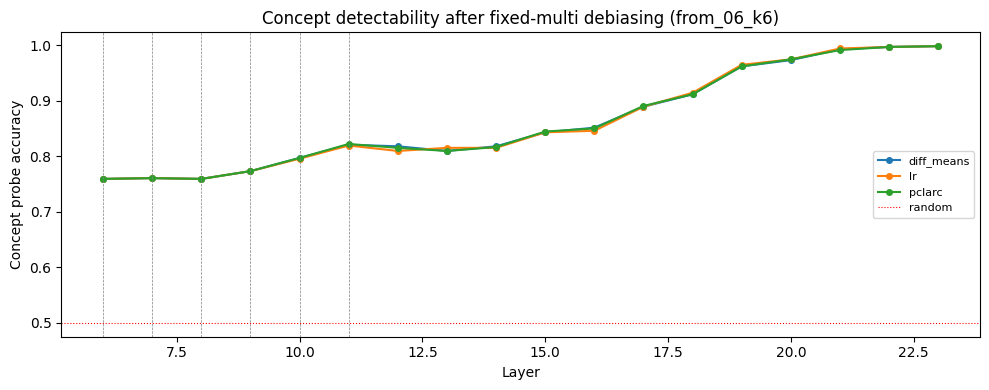

In [8]:
# Compare concept detection accuracy at each layer: raw vs fixed-multi debiased

df_meta_full = pd.read_csv(METADATA_PATH)
df_te = df_meta_full[df_meta_full['split'] == 'test'][['filename', CONCEPT]].reset_index(drop=True)

PLOT_DIR = ROOT / 'notebooks' / 'results' / 'multiple_debias' / CONCEPT / 'fixed_multi'
PLOT_DIR.mkdir(parents=True, exist_ok=True)

fig, ax = plt.subplots(figsize=(10, 4))

for method in METHODS:
    out_base = DATA_OUT / method / run_key
    accs = []
    for l in range(START_LAYER, NUM_LAYERS_MODEL):
        p = out_base / 'test' / f'layer_{l:02d}.parquet'
        if not p.exists():
            continue
        df_l = pd.read_parquet(p).merge(df_te, on='filename', how='left')
        feat_cols = [c for c in df_l.columns if c not in ('filename', CONCEPT)]
        X = df_l[feat_cols].values.astype(np.float64)
        y = df_l[CONCEPT].values
        from sklearn.linear_model import LogisticRegression
        try:
            probe = LogisticRegression(C=0.1, max_iter=500)
            probe.fit(X, y)
            accs.append((l, probe.score(X, y)))
        except Exception:
            pass
    if accs:
        ls_vals, acc_vals = zip(*accs)
        ax.plot(ls_vals, acc_vals, marker='o', ms=4, label=method)

# Mark debiased layers
for l in debias_layers:
    ax.axvline(l, color='gray', lw=0.5, ls='--')

ax.axhline(0.5, color='red', lw=0.8, ls=':', label='random')
ax.set_xlabel('Layer')
ax.set_ylabel('Concept probe accuracy')
ax.set_title(f'Concept detectability after fixed-multi debiasing ({run_key})')
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(PLOT_DIR / f'probe_acc_{run_key}.png', dpi=150)
plt.show()